# EXAMEN STATISTIQUE

**Nom :** Abdoulaye DABO  
**Classe :** DIC1 - IABD  
**Année académique :** 2025 - 2026

##### Importation des librairies

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

##### 1. Chargement du fichier

In [3]:
file = pd.read_excel('./titanic.xls')

# Infos sur le dataset
# print(file.head(3))
# print(file.columns)
# print(file.index)
# file.dtypes
# file.describe()

##### 2. Afficher le nom des colonnes et stocker les dans une variable nommée “cols”

In [4]:
cols = file.columns
cols

Index(['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket',
       'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest'],
      dtype='object')

##### 3. Calculer la moyenne de la colonne “Age” nommer : “moyennetot”

In [5]:
moyennetot = file["age"].mean()
# moyennetot
print(f"Moyenne d'âge total : {moyennetot:.2f} ans")

Moyenne d'âge total : 29.88 ans


##### 4. Utiliser la boucle pour fournir les paramètres suivants

In [ ]:
# Initialisation des compteurs et des listes pour stocker les âges
nbH = 0
nbF = 0
liste_ages_H = []
liste_ages_F = []

# La boucle qui parcourt chaque ligne du fichier
for i in range(len(file)):
    genre = file.loc[i, 'sex']
    age = file.loc[i, 'age']
    
    if genre == 'male':
        nbH += 1
        # On vérifie si l'âge n'est pas vide (NaN) pour les calculs
        if pd.notnull(age):
            liste_ages_H.append(age)
            
    elif genre == 'female':
        nbF += 1
        if pd.notnull(age):
            liste_ages_F.append(age)

# Calcul des moyennes (Somme / Nombre d'éléments)
agH = sum(liste_ages_H) / len(liste_ages_H)
agF = sum(liste_ages_F) / len(liste_ages_F)

# Calcul des écarts-types (via Pandas pour plus de précision)
ecH = pd.Series(liste_ages_H).std()
ecF = pd.Series(liste_ages_F).std()


# Affichage des résultats
print("Statistiques des passagers du Titanic :")
print("----------------------------------------")
print(f"Nombre de passagers hommes : {nbH}")
print(f"Nombre de passagères femmes : {nbF}")
print(f"Moyenne d'âge des hommes : {agH:.2f} ans")
print(f"Moyenne d'âge des femmes : {agF:.2f} ans")
print(f"Écart type des âges des hommes : {ecH:.2f} ans")
print(f"Écart type des âges des femmes : {ecF:.2f} ans")

Statistiques des passagers du Titanic :
----------------------------------------
Nombre de passagers hommes : 843
Nombre de passagères femmes : 466
Moyenne d'âge des hommes : 30.59 ans
Moyenne d'âge des femmes : 28.69 ans
Écart type des âges des hommes : 14.28 ans
Écart type des âges des femmes : 14.58 ans


##### 5. Faire les trois figure (diagramme en bar) avec femme et homme sur l’axe des abcisses et le nombre pour fig1, la moyenne pour fig2 et l’ecart type pour fig3

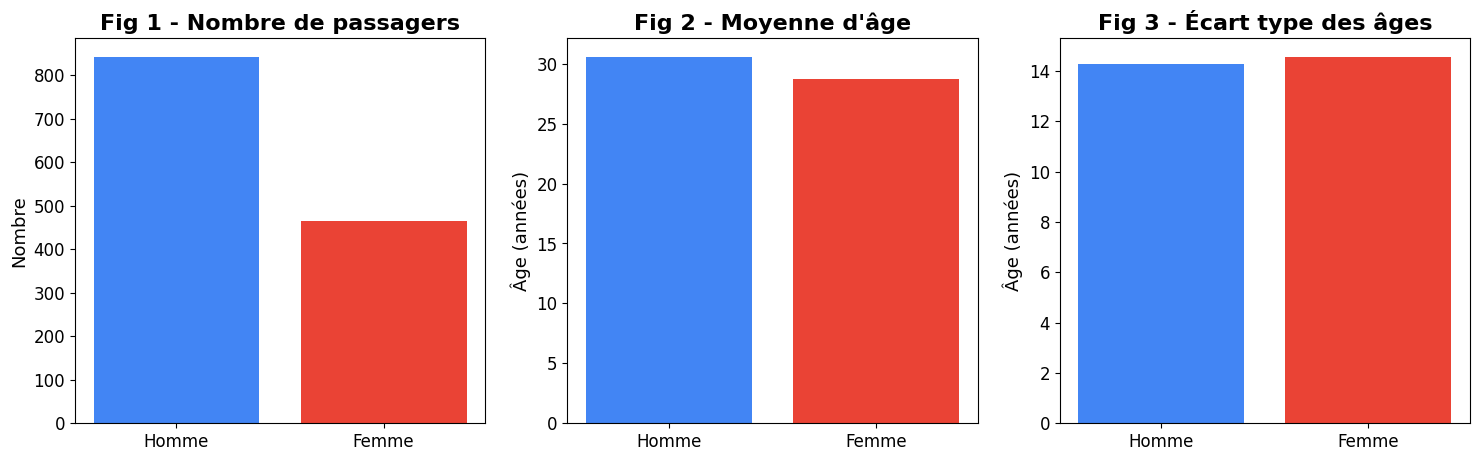

In [9]:
plt.rcParams['axes.spines.left'] = True

colors = ['#4285F4', '#EA4335'] 
labels = ['Homme', 'Femme']

count_data = [nbH, nbF]
mean_data  = [agH, agF]
std_data   = [ecH, ecF]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Fig 1 : Nombre de passagers
axes[0].bar(labels, count_data, color=colors)
axes[0].set_title('Fig 1 - Nombre de passagers', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Nombre', fontsize=13)
axes[0].tick_params(axis='both', labelsize=12)
axes[0].grid(False)

# Fig 2 : Moyenne d'âge
axes[1].bar(labels, mean_data, color=colors)
axes[1].set_title("Fig 2 - Moyenne d'âge", fontsize=16, fontweight='bold')
axes[1].set_ylabel('Âge (années)', fontsize=13)
axes[1].tick_params(axis='both', labelsize=12)
axes[1].grid(False)

# Fig 3 : Écart type des âges
axes[2].bar(labels, std_data, color=colors)
axes[2].set_title('Fig 3 - Écart type des âges', fontsize=16, fontweight='bold')
axes[2].set_ylabel('Âge (années)', fontsize=13)
axes[2].tick_params(axis='both', labelsize=12)
axes[2].grid(False)

plt.show()

##### 6. Donner le nom du passager homme qui a l'âge minimale

In [44]:
# Séparer hommes et femmes
hommes = file[file['sex'] == 'male']
femmes = file[file['sex'] == 'female']

nom_min_homme = hommes.loc[hommes['age'].idxmin(), 'name']
print("Homme le plus jeune :", nom_min_homme)

Homme le plus jeune : Danbom, Master. Gilbert Sigvard Emanuel


##### 7. Donner le nom du passager femme qui a l’age minimmale

In [52]:
nom_min_femme = femmes.loc[femmes['age'].idxmin(), 'name']
print("Femme la plus jeune :", nom_min_femme)

Femme la plus jeune : Dean, Miss. Elizabeth Gladys "Millvina"


##### 8. Donner le nom du passager homme qui a l'âge maximale

In [53]:
nom_max_homme = hommes.loc[hommes['age'].idxmax(), 'name']
print("Homme le plus vieux :", nom_max_homme)

Homme le plus vieux : Barkworth, Mr. Algernon Henry Wilson


##### 9. Donner le nom du passager femme qui a l’age maximale

In [54]:
nom_max_femme = femmes.loc[femmes['age'].idxmax(), 'name']
print("Femme la plus vieille :", nom_max_femme)

Femme la plus vieille : Cavendish, Mrs. Tyrell William (Julia Florence Siegel)


##### 10. Donner le nom du ou des passagers qui ont l'âge la plus proche de la moyenne pour les hommes et pour les femmes

In [43]:
diff_homme = (hommes['age'] - agH).abs()
diff_femme = (femmes['age'] - agF).abs()

proches_homme = hommes.loc[diff_homme == diff_homme.min(), 'name']
proches_femme = femmes.loc[diff_femme == diff_femme.min(), 'name']

print("Homme(s) proche(s) de la moyenne :", proches_homme.values)
print("Femme(s) proche(s) de la moyenne :", proches_femme.values)

Homme(s) proche(s) de la moyenne : ['Tomlin, Mr. Ernest Portage']
Femme(s) proche(s) de la moyenne : ['Allen, Miss. Elisabeth Walton' 'Bird, Miss. Ellen'
 'Chapman, Mrs. John Henry (Sara Elizabeth Lawry)'
 'Faunthorpe, Mrs. Lizzie (Elizabeth Anne Wilkinson)'
 'Hold, Mrs. Stephen (Annie Margaret Hill)' 'Nye, Mrs. (Elizabeth Ramell)'
 'Weisz, Mrs. Leopold (Mathilde Francoise Pede)'
 'Wells, Mrs. Arthur Henry ("Addie" Dart Trevaskis)'
 'Nieminen, Miss. Manta Josefina'
 'Palsson, Mrs. Nils (Alma Cornelia Berglund)'
 'Strom, Mrs. Wilhelm (Elna Matilda Persson)'
 'Touma, Mrs. Darwis (Hanne Youssef Razi)']
